# Module 3 — Specificity vs Vagueness Scoring

This notebook implements **Module 3** of the STR completeness scoring system.

Module 3 asks:

> Is the STR narrative specific, evidence-based, and analyst-useful — or is it vague, generic, and boilerplate?

This is different from Module 2:

- **Module 2** checks whether key narrative signals exist.
- **Module 3** checks the *quality of the language*: whether the report uses exact amounts, dates, transaction counts, counterparties, typology, and profile comparison instead of vague phrases like "suspicious transaction" or "unusual activity."

The output is a **0 to 1 specificity score** plus a **gap explanation** for every STR.

In [ ]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

DATA_PATH = "xml_output.csv"
OUTPUT_CSV = "module3_specificity_vagueness_scores.csv"

df = pd.read_csv(DATA_PATH)

print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Narrative column exists:", "report_reason" in df.columns)

df[["report_report_id", "report_reason"]].head()

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-2_fpdsyc because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Rows: 276
Columns: 501
Narrative column exists: True


,report_report_id,report_reason
0,RPT-2026-000001,Suspicious transaction observed.
1,RPT-2026-000002,During the branch's periodic transaction-monit...
2,RPT-2026-000003,During the branch's periodic transaction-monit...
3,RPT-2026-000004,During the branch's periodic transaction-monit...
4,RPT-2026-000005,Suspicious transaction observed.


## 1. Module 3 scoring idea

A strong narrative is not just long. It should be **specific**.

Specificity means the narrative includes concrete facts such as:

- exact amount
- exact transaction date or date range
- number of transactions
- customer/account-holder context
- counterparties or fund-flow direction
- KYC/profile comparison
- concrete red-flag typology
- account/reference traceability

Vagueness means the narrative relies on generic words without evidence, such as:

- suspicious transaction
- unusual activity
- large amounts
- appears suspicious
- may be related to
- flagged for review

The final score is:

> specificity evidence score − vagueness penalty

In [2]:
SPECIFICITY_WEIGHTS = {
    "has_specific_amount": 0.18,
    "has_specific_date": 0.14,
    "has_transaction_count": 0.12,
    "has_specific_party_context": 0.13,
    "has_counterparty_context": 0.10,
    "has_profile_comparison": 0.13,
    "has_specific_red_flag_reason": 0.12,
    "has_reference_trace": 0.08,
    "length_ok": 0.10,
}

weights_df = pd.DataFrame([
    {"specificity_signal": k, "weight": v, "percent": f"{v*100:.0f}%"}
    for k, v in SPECIFICITY_WEIGHTS.items()
]).sort_values("weight", ascending=False).reset_index(drop=True)

display(weights_df)
print("Total positive weight:", round(sum(SPECIFICITY_WEIGHTS.values()), 4))

,specificity_signal,weight,percent
0,has_specific_amount,0.18,18%
1,has_specific_date,0.14,14%
2,has_specific_party_context,0.13,13%
3,has_profile_comparison,0.13,13%
4,has_transaction_count,0.12,12%
5,has_specific_red_flag_reason,0.12,12%
6,has_counterparty_context,0.10,10%
7,length_ok,0.10,10%
8,has_reference_trace,0.08,8%


Total positive weight: 1.1


## 2. Vague phrase dictionary

These phrases are not always wrong by themselves.

For example, "inconsistent with profile" can be useful if the narrative also gives income, amount, date, and transaction pattern.

But if these phrases appear without concrete evidence, the report becomes weak. Module 3 therefore treats them as a **small penalty**, while fully generic narratives receive a large penalty.

In [3]:
GENERIC_NARRATIVES = {
    "suspicious transaction observed.",
    "suspicious transaction observed",
    "suspicious activity observed.",
    "suspicious activity observed",
}

VAGUE_PHRASES = [
    "unusual activity",
    "suspicious behavior",
    "suspicious behaviour",
    "suspicious transaction",
    "large amount",
    "large amounts",
    "without apparent reason",
    "inconsistent with profile",
    "may be related to",
    "it is suspected that",
    "could potentially",
    "appears to be",
    "seems suspicious",
    "flagged for review",
    "unusual pattern",
    "cannot be explained",
    "no apparent economic purpose",
    "not commensurate with profile",
]

HEDGING_PHRASES = [
    "may be",
    "might be",
    "could be",
    "potentially",
    "appears",
    "seems",
    "suspected",
    "possible",
    "possibly",
]

print("Generic narrative patterns:", len(GENERIC_NARRATIVES))
print("Vague phrase patterns:", len(VAGUE_PHRASES))
print("Hedging phrase patterns:", len(HEDGING_PHRASES))

Generic narrative patterns: 4
Vague phrase patterns: 18
Hedging phrase patterns: 9


## 3. Regex rules for concrete facts

In [4]:
AMOUNT_RE = re.compile(
    r"\b(?:NPR|Rs\.?|रु)?\s*\d{1,3}(?:,\d{2,3})+(?:\.\d+)?\b|"
    r"\b\d+(?:\.\d+)?\s*(?:NPR|Rs\.?)\b",
    re.IGNORECASE,
)

DATE_RE = re.compile(
    r"\b\d{4}[-/]\d{1,2}[-/]\d{1,2}\b|"
    r"\b\d{1,2}[-/]\d{1,2}[-/]\d{2,4}\b"
)

TRANSACTION_COUNT_RE = re.compile(
    r"\b\d+\s+transaction\(s\)\b|\b\d+\s+transactions?\b",
    re.IGNORECASE,
)

PARTY_CONTEXT_RE = re.compile(
    r"\baccount held by\b|\bcustomer\b|\bclient\b|\baccount holder\b|\bholder\b",
    re.IGNORECASE,
)

COUNTERPARTY_CONTEXT_RE = re.compile(
    r"\bcounterpart(?:y|ies)\b|\bprincipal counterparties observed were\b|"
    r"\brouted to\b|\bbeneficiar(?:y|ies)\b|\breceiver\b|\bsender\b",
    re.IGNORECASE,
)

PROFILE_COMPARISON_RE = re.compile(
    r"\bKYC\b|\bdeclared income\b|\bincome profile\b|\bprofile\b|"
    r"\busual corridor\b|\bcustomer has been with\b|\brelationship\b|"
    r"\badverse media\b|\bsanctions\b",
    re.IGNORECASE,
)

SPECIFIC_RED_FLAG_RE = re.compile(
    r"\bthreshold\b|\bstructuring\b|\blayering\b|\bfan in\b|\bfan out\b|"
    r"\brapid succession\b|\bvelocity\b|\bcross-border\b|\bbehavioural change\b|"
    r"\bbehavioral change\b|\bcash withdrawal\b|\bcash deposit\b|"
    r"\bACH transfer\b|\bwire\b|\bcard payment\b",
    re.IGNORECASE,
)

REFERENCE_TRACE_RE = re.compile(
    r"\b(?:account|acct|a/c|reference|ref|internal ref|txn|transaction no\.?|"
    r"transaction number)\s*[:#-]?\s*[A-Z0-9-]{5,}\b|"
    r"\b\d{8,16}\b",
    re.IGNORECASE,
)

print("Concrete fact regex rules loaded.")

Concrete fact regex rules loaded.


## 4. Scoring functions

In [5]:
def count_phrase_matches(text, phrases):
    text_lower = str(text).lower()
    return sum(1 for phrase in phrases if phrase in text_lower)


def extract_specificity_signals(text, min_words=80):
    if pd.isna(text):
        text = ""

    text = str(text).strip()
    normalized = re.sub(r"\s+", " ", text.lower()).strip()
    word_count = len(text.split())

    vague_phrase_count = count_phrase_matches(text, VAGUE_PHRASES)
    hedging_phrase_count = count_phrase_matches(text, HEDGING_PHRASES)

    signals = {
        "word_count": word_count,
        "is_generic_narrative": normalized in GENERIC_NARRATIVES,
        "vague_phrase_count": vague_phrase_count,
        "hedging_phrase_count": hedging_phrase_count,
        "specific_amount_count": len(AMOUNT_RE.findall(text)),
        "specific_date_count": len(DATE_RE.findall(text)),
        "transaction_count_mentions": len(TRANSACTION_COUNT_RE.findall(text)),
        "red_flag_mentions": len(SPECIFIC_RED_FLAG_RE.findall(text)),
        "has_specific_amount": bool(AMOUNT_RE.search(text)),
        "has_specific_date": bool(DATE_RE.search(text)),
        "has_transaction_count": bool(TRANSACTION_COUNT_RE.search(text)),
        "has_specific_party_context": bool(PARTY_CONTEXT_RE.search(text)),
        "has_counterparty_context": bool(COUNTERPARTY_CONTEXT_RE.search(text)),
        "has_profile_comparison": bool(PROFILE_COMPARISON_RE.search(text)),
        "has_specific_red_flag_reason": bool(SPECIFIC_RED_FLAG_RE.search(text)),
        "has_reference_trace": bool(REFERENCE_TRACE_RE.search(text)),
        "length_ok": word_count >= min_words,
    }
    return signals


def explain_specificity_gaps(signals):
    gaps = []

    if signals["is_generic_narrative"]:
        gaps.append("Narrative is boilerplate/generic and gives no concrete facts.")

    if signals["vague_phrase_count"] > 0:
        gaps.append(
            f"Narrative contains {signals['vague_phrase_count']} vague phrase(s); replace vague claims with exact facts."
        )

    if signals["hedging_phrase_count"] > 0:
        gaps.append(
            f"Narrative contains {signals['hedging_phrase_count']} hedging phrase(s); explain the evidence supporting the suspicion."
        )

    if not signals["has_specific_amount"]:
        gaps.append("No specific amount is stated.")
    if not signals["has_specific_date"]:
        gaps.append("No specific date or date range is stated.")
    if not signals["has_transaction_count"]:
        gaps.append("No transaction count is stated.")
    if not signals["has_specific_party_context"]:
        gaps.append("Customer/account-holder context is missing or vague.")
    if not signals["has_counterparty_context"]:
        gaps.append("Counterparty or fund-flow direction is missing.")
    if not signals["has_profile_comparison"]:
        gaps.append("Narrative does not compare activity with KYC/profile/expected behavior.")
    if not signals["has_specific_red_flag_reason"]:
        gaps.append("Narrative does not identify a concrete red-flag pattern or typology.")
    if not signals["has_reference_trace"]:
        gaps.append("No account/reference/transaction identifier is included in the narrative.")
    if not signals["length_ok"]:
        gaps.append("Narrative is too short for a specific analytical explanation.")

    return gaps if gaps else ["Narrative language is specific and analyst-useful."]


def score_specificity(text, min_words=80):
    signals = extract_specificity_signals(text, min_words=min_words)

    positive_score = sum(
        SPECIFICITY_WEIGHTS[name] * float(bool(signals[name]))
        for name in SPECIFICITY_WEIGHTS
    )

    generic_penalty = 0.70 if signals["is_generic_narrative"] else 0.0
    vague_penalty = min(signals["vague_phrase_count"] * 0.05, 0.25)
    hedging_penalty = min(signals["hedging_phrase_count"] * 0.04, 0.20)

    total_penalty = generic_penalty + vague_penalty + hedging_penalty
    score = max(0.0, min(1.0, positive_score - total_penalty))

    details = {
        "signals": signals,
        "positive_score_before_penalty": round(positive_score, 4),
        "generic_penalty": round(generic_penalty, 4),
        "vague_penalty": round(vague_penalty, 4),
        "hedging_penalty": round(hedging_penalty, 4),
        "total_penalty": round(total_penalty, 4),
        "gaps": explain_specificity_gaps(signals),
    }

    return round(score, 4), details


example_text = df.loc[0, "report_reason"]
score, details = score_specificity(example_text)

print("Example narrative:")
print(example_text)
print("\\nModule 3 score:", score)
print("\\nPositive score before penalty:", details["positive_score_before_penalty"])
print("Total penalty:", details["total_penalty"])
print("\\nSignals:")
display(pd.DataFrame([details["signals"]]))
print("\\nGaps:")
for gap in details["gaps"]:
    print("-", gap)

Example narrative:
Suspicious transaction observed.
\nModule 3 score: 0.0
\nPositive score before penalty: 0.0
Total penalty: 0.75
\nSignals:


,word_count,is_generic_narrative,vague_phrase_count,hedging_phrase_count,specific_amount_count,specific_date_count,transaction_count_mentions,red_flag_mentions,has_specific_amount,has_specific_date,has_transaction_count,has_specific_party_context,has_counterparty_context,has_profile_comparison,has_specific_red_flag_reason,has_reference_trace,length_ok
0,3,True,1,0,0,0,0,0,False,False,False,False,False,False,False,False,False


\nGaps:
- Narrative is boilerplate/generic and gives no concrete facts.
- Narrative contains 1 vague phrase(s); replace vague claims with exact facts.
- No specific amount is stated.
- No specific date or date range is stated.
- No transaction count is stated.
- Customer/account-holder context is missing or vague.
- Counterparty or fund-flow direction is missing.
- Narrative does not compare activity with KYC/profile/expected behavior.
- Narrative does not identify a concrete red-flag pattern or typology.
- No account/reference/transaction identifier is included in the narrative.
- Narrative is too short for a specific analytical explanation.


## 5. Apply Module 3 to every STR report

In [6]:
scored_rows = []

for _, row in df.iterrows():
    score, details = score_specificity(row["report_reason"])
    signals = details["signals"]

    out = {
        "report_report_id": row.get("report_report_id"),
        "module3_specificity_score": score,
        "positive_score_before_penalty": details["positive_score_before_penalty"],
        "generic_penalty": details["generic_penalty"],
        "vague_penalty": details["vague_penalty"],
        "hedging_penalty": details["hedging_penalty"],
        "total_penalty": details["total_penalty"],
        "module3_gaps": " | ".join(details["gaps"]),
        "report_reason": row["report_reason"],
    }

    for key, value in signals.items():
        if isinstance(value, bool):
            out[key] = int(value)
        else:
            out[key] = value

    scored_rows.append(out)

module3_df = pd.DataFrame(scored_rows)

def specificity_band(score):
    if score >= 0.75:
        return "Specific"
    if score >= 0.45:
        return "Moderately specific"
    return "Vague / generic"

module3_df["specificity_band"] = module3_df["module3_specificity_score"].apply(specificity_band)

display(module3_df.head())

,report_report_id,module3_specificity_score,positive_score_before_penalty,generic_penalty,vague_penalty,hedging_penalty,total_penalty,module3_gaps,report_reason,word_count,is_generic_narrative,vague_phrase_count,hedging_phrase_count,specific_amount_count,specific_date_count,transaction_count_mentions,red_flag_mentions,has_specific_amount,has_specific_date,has_transaction_count,has_specific_party_context,has_counterparty_context,has_profile_comparison,has_specific_red_flag_reason,has_reference_trace,length_ok,specificity_band
0,RPT-2026-000001,0.0,0.00,0.7,0.05,0.0,0.75,Narrative is boilerplate/generic and gives no ...,Suspicious transaction observed.,3,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Vague / generic
1,RPT-2026-000002,1.0,1.02,0.0,0.00,0.0,0.00,No account/reference/transaction identifier is...,During the branch's periodic transaction-monit...,187,0,0,0,1,2,1,5,1,1,1,1,1,1,1,0,1,Specific
2,RPT-2026-000003,1.0,1.02,0.0,0.00,0.0,0.00,No account/reference/transaction identifier is...,During the branch's periodic transaction-monit...,190,0,0,0,1,2,1,6,1,1,1,1,1,1,1,0,1,Specific
3,RPT-2026-000004,1.0,1.02,0.0,0.00,0.0,0.00,No account/reference/transaction identifier is...,During the branch's periodic transaction-monit...,186,0,0,0,1,2,1,6,1,1,1,1,1,1,1,0,1,Specific
4,RPT-2026-000005,0.0,0.00,0.7,0.05,0.0,0.75,Narrative is boilerplate/generic and gives no ...,Suspicious transaction observed.,3,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Vague / generic


## 6. Module 3 summary

In [7]:
summary = pd.DataFrame({
    "metric": [
        "Total STR reports",
        "Average Module 3 specificity score",
        "Median Module 3 specificity score",
        "Minimum Module 3 specificity score",
        "Maximum Module 3 specificity score",
        "Generic/boilerplate narratives",
        "Reports with at least one vague phrase",
        "Reports with hedging language",
    ],
    "value": [
        len(module3_df),
        round(module3_df["module3_specificity_score"].mean(), 4),
        round(module3_df["module3_specificity_score"].median(), 4),
        round(module3_df["module3_specificity_score"].min(), 4),
        round(module3_df["module3_specificity_score"].max(), 4),
        int(module3_df["is_generic_narrative"].sum()),
        int((module3_df["vague_phrase_count"] > 0).sum()),
        int((module3_df["hedging_phrase_count"] > 0).sum()),
    ]
})

display(summary)

band_counts = module3_df["specificity_band"].value_counts().rename_axis("band").reset_index(name="count")
display(band_counts)

,metric,value
0,Total STR reports,276.0000
1,Average Module 3 specificity score,0.6377
2,Median Module 3 specificity score,1.0000
3,Minimum Module 3 specificity score,0.0000
4,Maximum Module 3 specificity score,1.0000
5,Generic/boilerplate narratives,100.0000
6,Reports with at least one vague phrase,100.0000
7,Reports with hedging language,0.0000


,band,count
0,Specific,176
1,Vague / generic,100


## 7. Specificity signal coverage

In [8]:
signal_cols = list(SPECIFICITY_WEIGHTS.keys())

signal_coverage = []
for col in signal_cols:
    count = int(module3_df[col].sum())
    signal_coverage.append({
        "specificity_signal": col,
        "reports_with_signal": count,
        "coverage_percent": round(count / len(module3_df) * 100, 2),
        "weight": SPECIFICITY_WEIGHTS[col],
    })

signal_coverage_df = pd.DataFrame(signal_coverage).sort_values("coverage_percent", ascending=False)
display(signal_coverage_df)

,specificity_signal,reports_with_signal,coverage_percent,weight
0,has_specific_amount,176,63.77,0.18
1,has_specific_date,176,63.77,0.14
2,has_transaction_count,176,63.77,0.12
3,has_specific_party_context,176,63.77,0.13
4,has_counterparty_context,176,63.77,0.10
5,has_profile_comparison,176,63.77,0.13
6,has_specific_red_flag_reason,176,63.77,0.12
8,length_ok,176,63.77,0.10
7,has_reference_trace,0,0.00,0.08


## 8. Visualizations

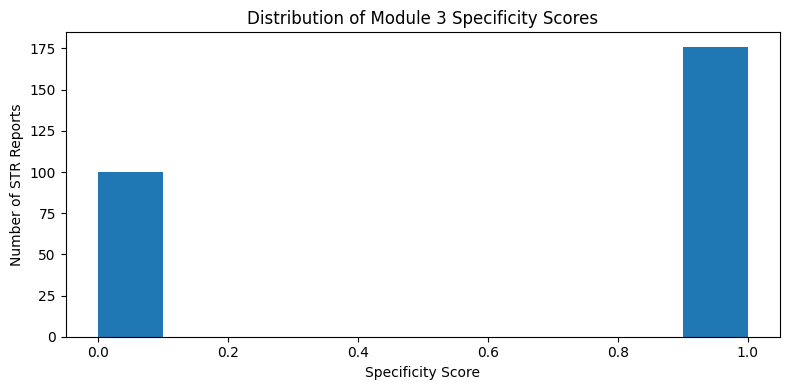

In [9]:
plt.figure(figsize=(8, 4))
plt.hist(module3_df["module3_specificity_score"], bins=10)
plt.title("Distribution of Module 3 Specificity Scores")
plt.xlabel("Specificity Score")
plt.ylabel("Number of STR Reports")
plt.tight_layout()
plt.show()

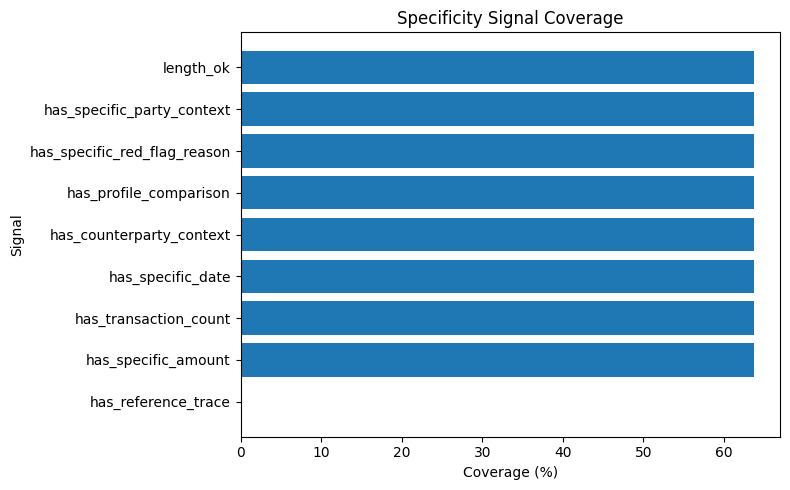

In [10]:
plot_df = signal_coverage_df.sort_values("coverage_percent")

plt.figure(figsize=(8, 5))
plt.barh(plot_df["specificity_signal"], plot_df["coverage_percent"])
plt.title("Specificity Signal Coverage")
plt.xlabel("Coverage (%)")
plt.ylabel("Signal")
plt.tight_layout()
plt.show()

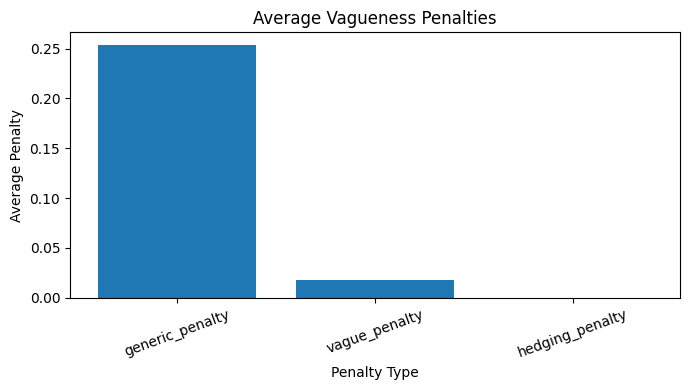

,penalty_type,average_penalty
0,generic_penalty,0.253623
1,vague_penalty,0.018116
2,hedging_penalty,0.000000


In [11]:
penalty_summary = pd.DataFrame({
    "penalty_type": ["generic_penalty", "vague_penalty", "hedging_penalty"],
    "average_penalty": [
        module3_df["generic_penalty"].mean(),
        module3_df["vague_penalty"].mean(),
        module3_df["hedging_penalty"].mean(),
    ],
})

plt.figure(figsize=(7, 4))
plt.bar(penalty_summary["penalty_type"], penalty_summary["average_penalty"])
plt.title("Average Vagueness Penalties")
plt.xlabel("Penalty Type")
plt.ylabel("Average Penalty")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

display(penalty_summary)

## 9. Most common vague phrases

This helps explain what type of language is reducing specificity.

,phrase,count
0,suspicious transaction,100


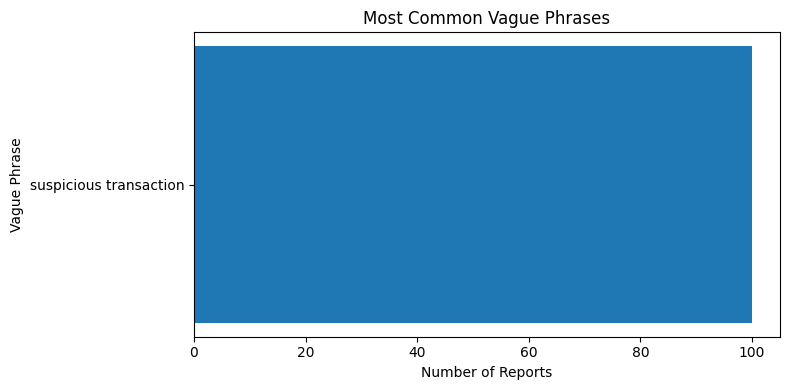

In [12]:
phrase_counts = []

for phrase in VAGUE_PHRASES:
    count = df["report_reason"].fillna("").str.lower().str.contains(re.escape(phrase), regex=True).sum()
    if count > 0:
        phrase_counts.append({"phrase": phrase, "count": int(count)})

vague_phrase_df = pd.DataFrame(phrase_counts).sort_values("count", ascending=False)

display(vague_phrase_df)

if not vague_phrase_df.empty:
    plot_df = vague_phrase_df.sort_values("count").tail(10)
    plt.figure(figsize=(8, 4))
    plt.barh(plot_df["phrase"], plot_df["count"])
    plt.title("Most Common Vague Phrases")
    plt.xlabel("Number of Reports")
    plt.ylabel("Vague Phrase")
    plt.tight_layout()
    plt.show()

## 10. Bottom reports: highest remediation priority

In [13]:
bottom_reports = module3_df.sort_values(
    ["module3_specificity_score", "word_count"],
    ascending=[True, True]
)[[
    "report_report_id",
    "module3_specificity_score",
    "specificity_band",
    "word_count",
    "is_generic_narrative",
    "vague_phrase_count",
    "hedging_phrase_count",
    "module3_gaps",
    "report_reason",
]].head(10)

display(bottom_reports)

,report_report_id,module3_specificity_score,specificity_band,word_count,is_generic_narrative,vague_phrase_count,hedging_phrase_count,module3_gaps,report_reason
0,RPT-2026-000001,0.0,Vague / generic,3,1,1,0,Narrative is boilerplate/generic and gives no ...,Suspicious transaction observed.
4,RPT-2026-000005,0.0,Vague / generic,3,1,1,0,Narrative is boilerplate/generic and gives no ...,Suspicious transaction observed.
8,RPT-2026-000009,0.0,Vague / generic,3,1,1,0,Narrative is boilerplate/generic and gives no ...,Suspicious transaction observed.
10,RPT-2026-000011,0.0,Vague / generic,3,1,1,0,Narrative is boilerplate/generic and gives no ...,Suspicious transaction observed.
12,RPT-2026-000013,0.0,Vague / generic,3,1,1,0,Narrative is boilerplate/generic and gives no ...,Suspicious transaction observed.
18,RPT-2026-000019,0.0,Vague / generic,3,1,1,0,Narrative is boilerplate/generic and gives no ...,Suspicious transaction observed.
20,RPT-2026-000021,0.0,Vague / generic,3,1,1,0,Narrative is boilerplate/generic and gives no ...,Suspicious transaction observed.
21,RPT-2026-000022,0.0,Vague / generic,3,1,1,0,Narrative is boilerplate/generic and gives no ...,Suspicious transaction observed.
23,RPT-2026-000024,0.0,Vague / generic,3,1,1,0,Narrative is boilerplate/generic and gives no ...,Suspicious transaction observed.
24,RPT-2026-000025,0.0,Vague / generic,3,1,1,0,Narrative is boilerplate/generic and gives no ...,Suspicious transaction observed.


## 11. Top reports: specific narrative examples

In [14]:
top_reports = module3_df.sort_values(
    ["module3_specificity_score", "word_count"],
    ascending=[False, False]
)[[
    "report_report_id",
    "module3_specificity_score",
    "specificity_band",
    "word_count",
    "specific_amount_count",
    "specific_date_count",
    "transaction_count_mentions",
    "red_flag_mentions",
    "vague_phrase_count",
    "module3_gaps",
    "report_reason",
]].head(10)

display(top_reports)

,report_report_id,module3_specificity_score,specificity_band,word_count,specific_amount_count,specific_date_count,transaction_count_mentions,red_flag_mentions,vague_phrase_count,module3_gaps,report_reason
2,RPT-2026-000003,1.0,Specific,190,1,2,1,6,0,No account/reference/transaction identifier is...,During the branch's periodic transaction-monit...
13,RPT-2026-000014,1.0,Specific,190,1,2,1,6,0,No account/reference/transaction identifier is...,During the branch's periodic transaction-monit...
34,RPT-2026-000035,1.0,Specific,190,1,2,1,6,0,No account/reference/transaction identifier is...,During the branch's periodic transaction-monit...
66,RPT-2026-000067,1.0,Specific,190,1,2,1,6,0,No account/reference/transaction identifier is...,During the branch's periodic transaction-monit...
97,RPT-2026-000098,1.0,Specific,190,1,2,1,6,0,No account/reference/transaction identifier is...,During the branch's periodic transaction-monit...
6,RPT-2026-000007,1.0,Specific,189,1,2,1,6,0,No account/reference/transaction identifier is...,During the branch's periodic transaction-monit...
124,RPT-2026-000125,1.0,Specific,189,1,2,1,4,0,No account/reference/transaction identifier is...,During the branch's periodic transaction-monit...
131,RPT-2026-000132,1.0,Specific,189,1,2,1,3,0,No account/reference/transaction identifier is...,During the branch's periodic transaction-monit...
144,RPT-2026-000145,1.0,Specific,189,1,2,1,5,0,No account/reference/transaction identifier is...,During the branch's periodic transaction-monit...
184,RPT-2026-000185,1.0,Specific,189,1,2,1,3,0,No account/reference/transaction identifier is...,During the branch's periodic transaction-monit...


## 12. How Module 3 should be explained in the final project

Suggested explanation:

> Module 3 penalizes generic or vague STR narratives and rewards concrete, quantified descriptions. A report that merely says "Suspicious transaction observed" receives a very low score. A stronger report should state the amount, date range, number of transactions, involved parties, counterparties, risk typology, and why the behavior is inconsistent with the customer's profile.

This helps the analyst know whether the narrative is actionable or whether it needs remediation.

## 13. Export Module 3 results

In [15]:
module3_df.to_csv(OUTPUT_CSV, index=False)
print("Saved:", OUTPUT_CSV)
print("Rows exported:", len(module3_df))

Saved: /mnt/data/module3_specificity_vagueness_scores.csv
Rows exported: 276
